In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

Load the dataset

In [7]:
!pip install kagglehub

In [3]:
file_path = '/kaggle/input/dnn-edgeiiot-dataset/DNN-EdgeIIoT-dataset.csv'
df = pd.read_csv(file_path)
df.head(5)

/tmp/ipykernel_31/323156701.py:2: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [4]:
# 2) Define target and features
target = 'Attack_label'

X = df.drop(columns=['Attack_label'])
y = df

Identify the label column

In [5]:
label_column = [col for col in df.columns if 'label' in col.lower()][0]

Encode categorical features and the label

In [6]:
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

Encode target to integer classes

In [7]:
target_encoder = LabelEncoder()
df[label_column] = target_encoder.fit_transform(df[label_column])
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,57650,58101,22987,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,7
1,57651,58100,22988,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,2,0,0.0,4.0,0.0,0.0,0.0,0,7
2,57652,58101,22987,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,7
3,57653,58101,22987,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,7
4,57654,58100,22988,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,2,24.0,0.0,0.0,0.0,0.0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2093397,43780,22988,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,1,1,0.0,0.0,0.0,0.0,0.0,1,2
2219197,2093398,121518,22988,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,1,1,0.0,0.0,0.0,0.0,0.0,1,2
2219198,2093399,104154,22988,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,1,1,0.0,0.0,0.0,0.0,0.0,1,2
2219199,2093400,50370,22988,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,1,1,0.0,0.0,0.0,0.0,0.0,1,2


Split features and labels

In [8]:
X = df.drop(label_column, axis=1)
y = df[label_column]


Standardize features

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

Train and Evaluate XGBoost

In [11]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

Evaluation

In [12]:
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_conf_matrix = confusion_matrix(y_test, xgb_pred)

In [13]:
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("\\nClassification Report for XGBoost:")
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 1.0000
\nClassification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841



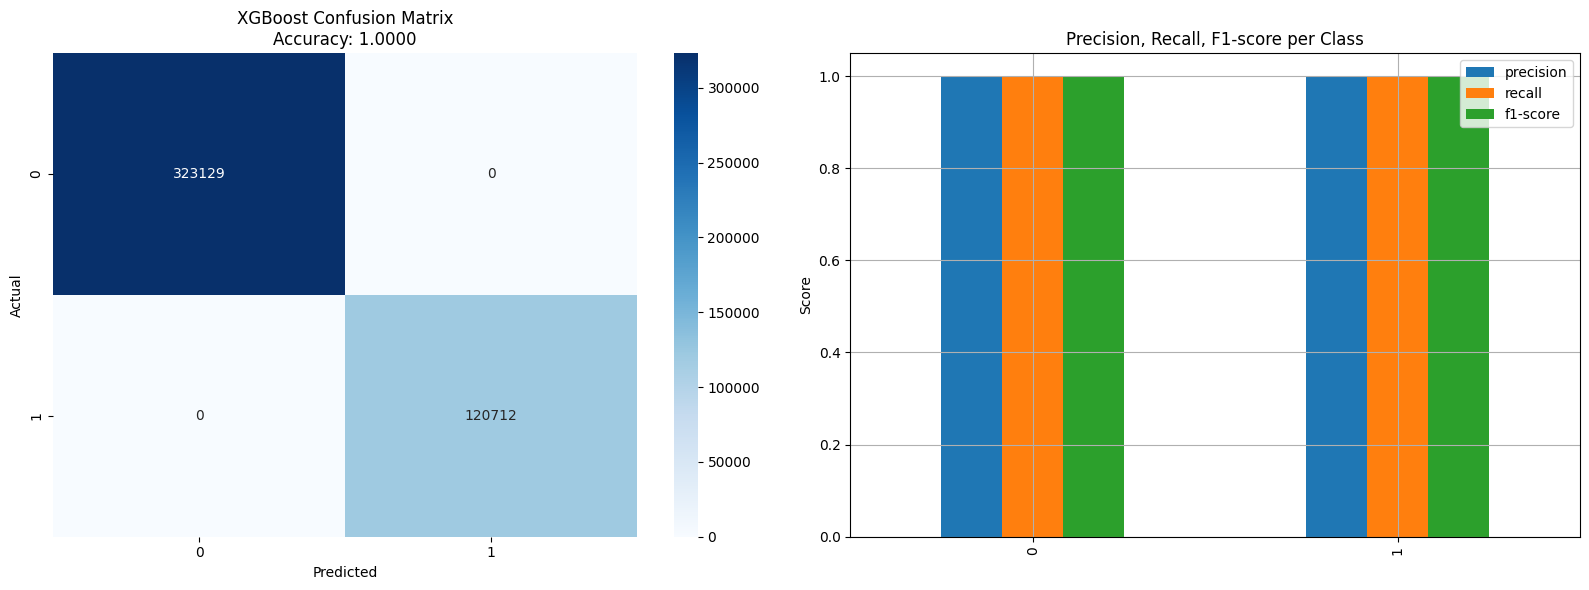

In [14]:
# Plot confusion matrix and bar chart for metrics
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix plot
sns.heatmap(xgb_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title(f'XGBoost Confusion Matrix\nAccuracy: {xgb_accuracy:.4f}')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')

# Classification metrics bar chart
report_df = pd.DataFrame(xgb_report).transpose()
report_df = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axs[1])
axs[1].set_title("Precision, Recall, F1-score per Class")
axs[1].set_ylabel("Score")
axs[1].legend(loc='upper right')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Random Forest model

In [15]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [16]:
# Accuracy and classification report
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_conf_matrix = confusion_matrix(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred)

In [17]:
# Print results
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report for Random Forest:")
print(rf_report)

Random Forest Accuracy: 1.0000

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841



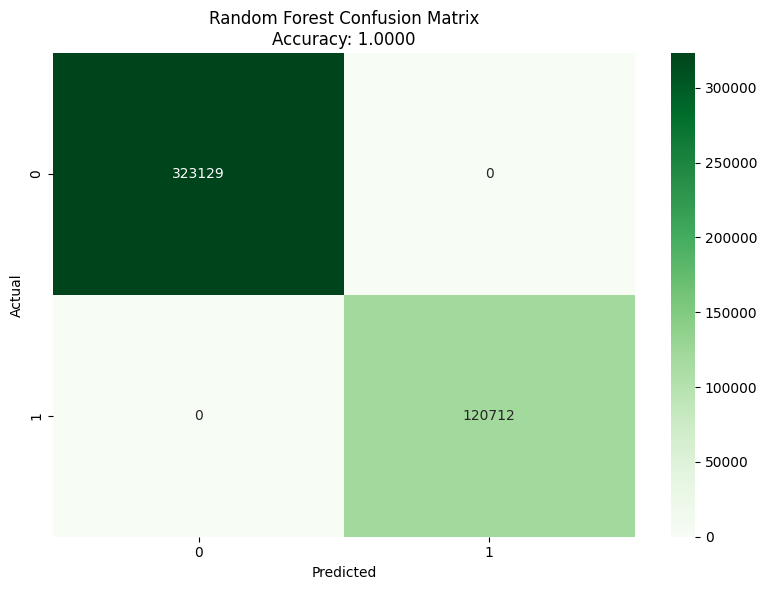

In [18]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title(f'Random Forest Confusion Matrix\nAccuracy: {rf_accuracy:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Multilayer Perceptron(MLP)

In [19]:
from sklearn.neural_network import MLPClassifier

# Train MLP Classifier
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

In [20]:
# Evaluate
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_conf_matrix = confusion_matrix(y_test, mlp_pred)
mlp_report = classification_report(y_test, mlp_pred)

In [21]:
# Print results
print(f"MLP Accuracy: {mlp_accuracy:.4f}")
print("\nClassification Report for MLP:")
print(mlp_report)


MLP Accuracy: 1.0000

Classification Report for MLP:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841



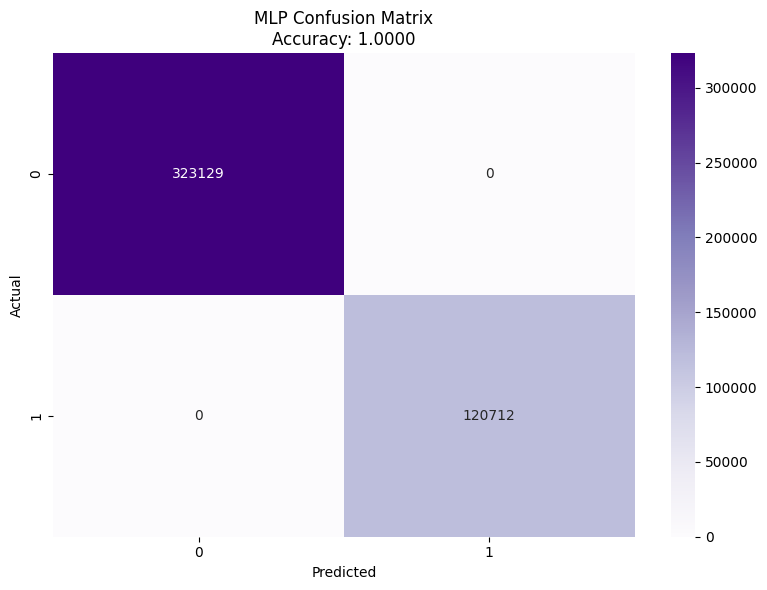

In [22]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(mlp_conf_matrix, annot=True, fmt='d', cmap='Purples')
plt.title(f'MLP Confusion Matrix\nAccuracy: {mlp_accuracy:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Model Comparison for Random Forest, MLP and XG Boost

In [23]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
conf_matrices = {}

In [24]:
# Train, predict, and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    results[name] = accuracy
    conf_matrices[name] = conf_matrix
    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")



Random Forest Accuracy: 1.0000
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841


MLP Accuracy: 1.0000
Classification Report for MLP:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841


XGBoost Accuracy: 1.0000
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


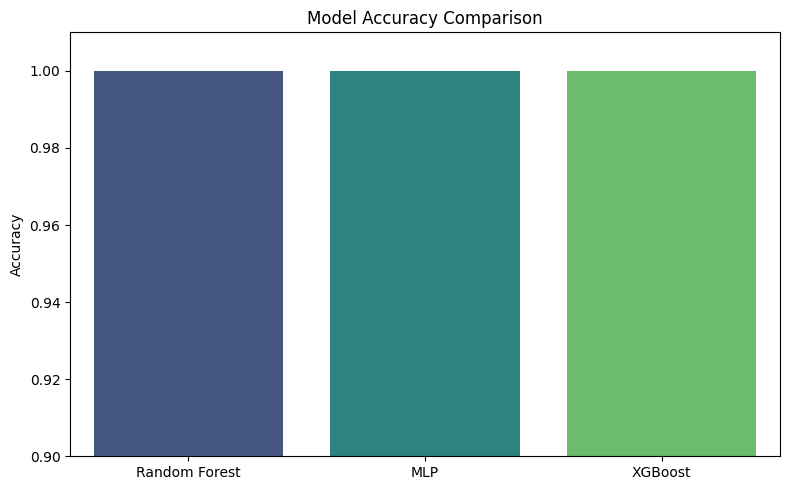

In [25]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))
model_names = list(results.keys())
accuracies = list(results.values())
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

PART - B

In [26]:
# Encode object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]


In [27]:
# Encode the target labels
label_encoder = LabelEncoder()
df[label_column] = label_encoder.fit_transform(df[label_column])

In [28]:
# Prepare features and labels
X = df.drop(label_column, axis=1)
y = df[label_column]

In [29]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [31]:
# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [32]:
# Evaluate all models on clean data
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy (Clean Data): {accuracy:.4f}")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")


Random Forest Accuracy (Clean Data): 1.0000
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841


MLP Accuracy (Clean Data): 1.0000
Classification Report for MLP:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           1       1.00      1.00      1.00    120712

    accuracy                           1.00    443841
   macro avg       1.00      1.00      1.00    443841
weighted avg       1.00      1.00      1.00    443841


XGBoost Accuracy (Clean Data): 1.0000
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    323129
           

In [33]:
# Check what unique labels exist in your target variable
unique_labels = y.unique()
print("Unique labels in the dataset:", unique_labels)

# Check label distribution (as percentages)
label_distribution = y.value_counts(normalize=True).sort_index()
print("\nLabel distribution in the dataset:")
print(label_distribution)


Unique labels in the dataset: [0 1]

Label distribution in the dataset:
Attack_label
0    0.728029
1    0.271971
Name: proportion, dtype: float64


XG Boost

XGBoost - 0% label flip → Accuracy: 1.0000
XGBoost - 5% label flip → Accuracy: 1.0000
XGBoost - 10% label flip → Accuracy: 0.9992
XGBoost - 15% label flip → Accuracy: 0.7359
XGBoost - 20% label flip → Accuracy: 0.7281
XGBoost - 25% label flip → Accuracy: 0.7280
XGBoost - 30% label flip → Accuracy: 0.7280


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


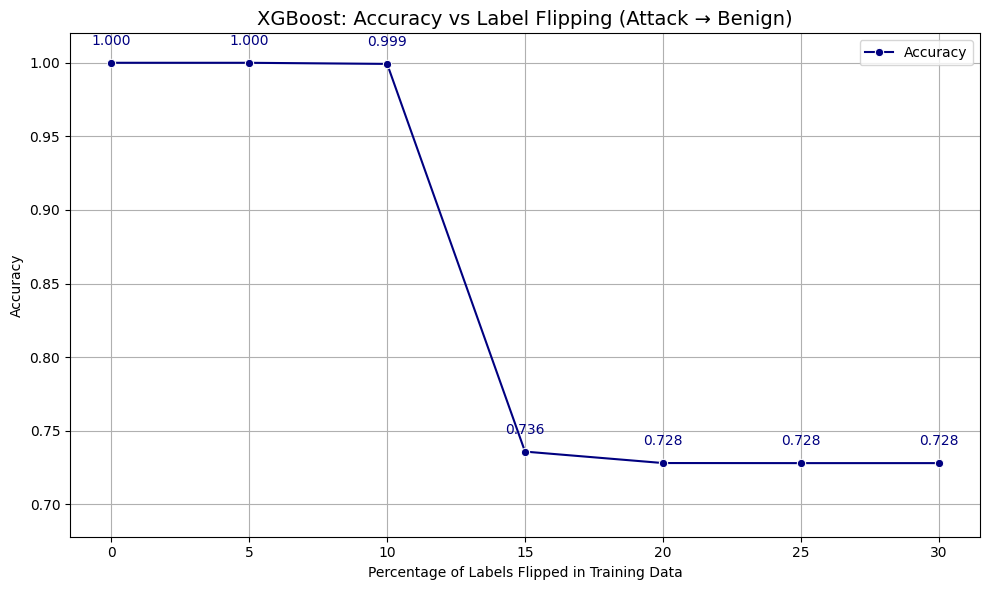

In [34]:
from sklearn.metrics import f1_score, accuracy_score
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

label_encoder = LabelEncoder()
df[label_column] = label_encoder.fit_transform(df[label_column])

X = df.drop(label_column, axis=1)
y = df[label_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Function to flip only attack labels (1 → 0)
def flip_attack_labels_only(y, percentage, attack_label=1, benign_label=0):
    y_poisoned = pd.Series(y).copy()
    attack_indices = y_poisoned[y_poisoned == attack_label].index
    n_flip = int((percentage / 100) * len(y))
    if len(attack_indices) < n_flip:
        n_flip = len(attack_indices)
    flip_indices = np.random.choice(attack_indices, size=n_flip, replace=False)
    y_poisoned.loc[flip_indices] = benign_label
    return y_poisoned

# Accuracy evaluation loop
flip_percentages = [0, 5, 10, 15, 20, 25, 30]
xgb_accuracies = []

for p in flip_percentages:
    poisoned_y_train = flip_attack_labels_only(y_train, p)
    xgb_model = xgb.XGBClassifier(eval_metric='logloss', base_score=0.5)
    xgb_model.fit(X_train, poisoned_y_train)
    y_pred = xgb_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    xgb_accuracies.append(acc)
    print(f"XGBoost - {p}% label flip → Accuracy: {acc:.4f}")

# Plot Accuracy Only
plt.figure(figsize=(10, 6))
sns.lineplot(x=flip_percentages, y=xgb_accuracies, marker='o', label='Accuracy', color='navy')

# Annotate accuracy values
for x, y in zip(flip_percentages, xgb_accuracies):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', color='navy')

plt.title("XGBoost: Accuracy vs Label Flipping (Attack → Benign)", fontsize=14)
plt.xlabel("Percentage of Labels Flipped in Training Data")
plt.ylabel("Accuracy")
plt.ylim(min(xgb_accuracies) - 0.05, 1.02)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest

Random Forest - 0% label flip → Accuracy: 1.0000
Random Forest - 5% label flip → Accuracy: 0.9932
Random Forest - 10% label flip → Accuracy: 0.9497
Random Forest - 15% label flip → Accuracy: 0.8219
Random Forest - 20% label flip → Accuracy: 0.7441
Random Forest - 25% label flip → Accuracy: 0.7296
Random Forest - 30% label flip → Accuracy: 0.7280


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


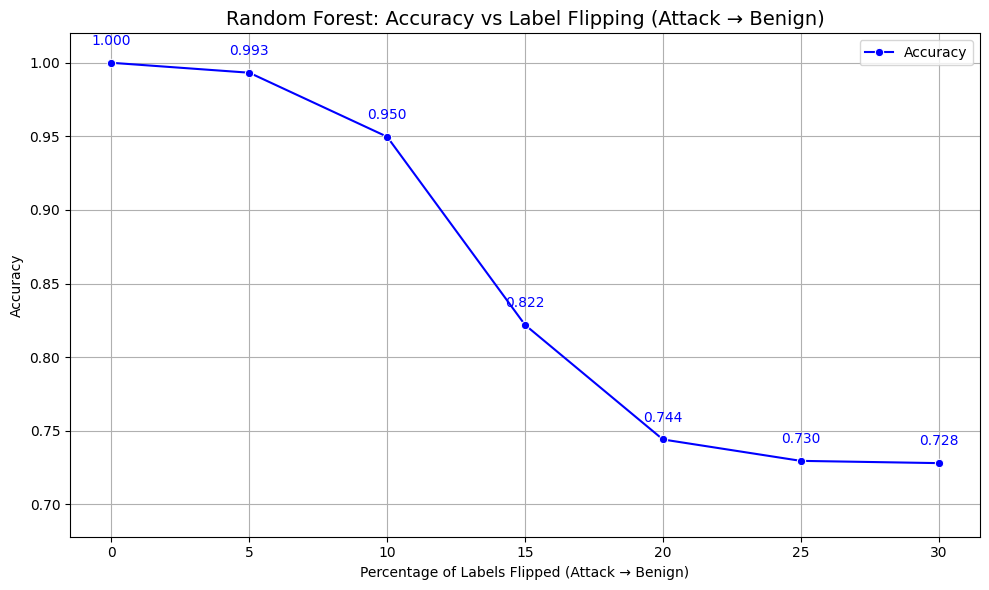

In [35]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

label_encoder = LabelEncoder()
df[label_column] = label_encoder.fit_transform(df[label_column])

X = df.drop(label_column, axis=1)
y = df[label_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Function to flip attack labels (1 → 0)
def flip_attack_labels_only(y, percentage, attack_label=1, benign_label=0):
    y_poisoned = pd.Series(y).copy()
    attack_indices = y_poisoned[y_poisoned == attack_label].index
    n_flip = int((percentage / 100) * len(y))
    if len(attack_indices) < n_flip:
        n_flip = len(attack_indices)
    flip_indices = np.random.choice(attack_indices, size=n_flip, replace=False)
    y_poisoned.loc[flip_indices] = benign_label
    return y_poisoned

# Accuracy evaluation under poisoning
flip_percentages = [0, 5, 10, 15, 20, 25, 30]
rf_accuracies = []

for p in flip_percentages:
    poisoned_y_train = flip_attack_labels_only(y_train, p)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, poisoned_y_train)
    y_pred = rf_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rf_accuracies.append(acc)
    print(f"Random Forest - {p}% label flip → Accuracy: {acc:.4f}")

# Plot Accuracy Only
plt.figure(figsize=(10, 6))
sns.lineplot(x=flip_percentages, y=rf_accuracies, marker='o', label='Accuracy', color='blue')

# Annotate points
for x, y in zip(flip_percentages, rf_accuracies):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', color='blue')

plt.title("Random Forest: Accuracy vs Label Flipping (Attack → Benign)", fontsize=14)
plt.xlabel("Percentage of Labels Flipped (Attack → Benign)")
plt.ylabel("Accuracy")
plt.ylim(min(rf_accuracies) - 0.05, 1.02)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


MLP

MLP - 0% label flip → Accuracy: 1.0000
MLP - 5% label flip → Accuracy: 1.0000
MLP - 10% label flip → Accuracy: 1.0000
MLP - 15% label flip → Accuracy: 0.7282
MLP - 20% label flip → Accuracy: 0.7280
MLP - 25% label flip → Accuracy: 0.7280
MLP - 30% label flip → Accuracy: 0.7280


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


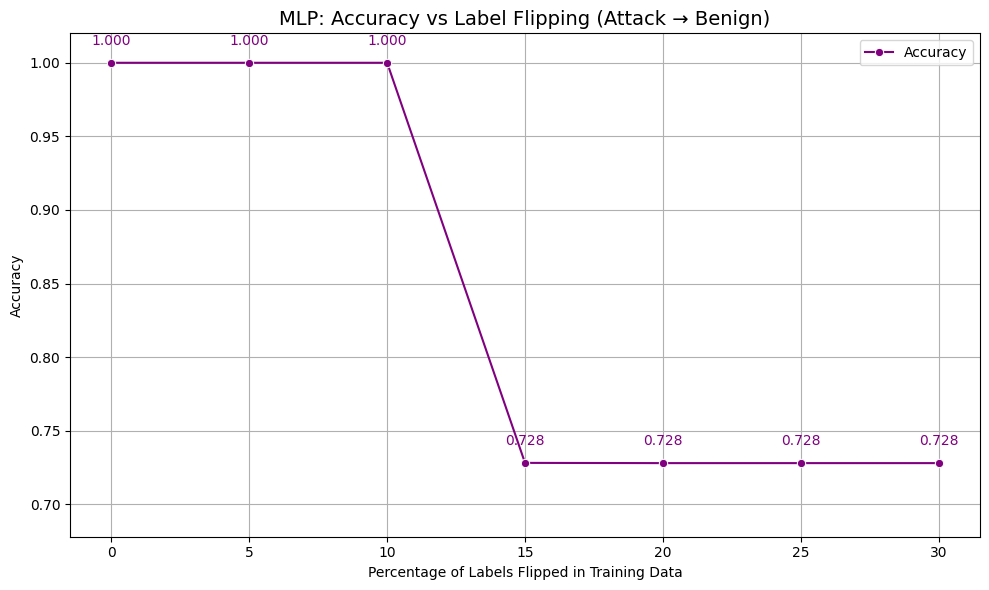

In [36]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

label_encoder = LabelEncoder()
df[label_column] = label_encoder.fit_transform(df[label_column])

X = df.drop(label_column, axis=1)
y = df[label_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Function to flip only attack labels (1 → 0)
def flip_attack_labels_only(y, percentage, attack_label=1, benign_label=0):
    y_poisoned = pd.Series(y).copy()
    attack_indices = y_poisoned[y_poisoned == attack_label].index
    n_flip = int((percentage / 100) * len(y))
    if len(attack_indices) < n_flip:
        n_flip = len(attack_indices)
    flip_indices = np.random.choice(attack_indices, size=n_flip, replace=False)
    y_poisoned.loc[flip_indices] = benign_label
    return y_poisoned

# Accuracy evaluation loop for MLP
flip_percentages = [0, 5, 10, 15, 20, 25, 30]
mlp_accuracies = []

for p in flip_percentages:
    poisoned_y_train = flip_attack_labels_only(y_train, p)
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    mlp_model.fit(X_train, poisoned_y_train)
    y_pred = mlp_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    mlp_accuracies.append(acc)
    print(f"MLP - {p}% label flip → Accuracy: {acc:.4f}")

# Plot Accuracy Only
plt.figure(figsize=(10, 6))
sns.lineplot(x=flip_percentages, y=mlp_accuracies, marker='o', label='Accuracy', color='purple')

# Annotate accuracy values
for x, y in zip(flip_percentages, mlp_accuracies):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', color='purple')

plt.title("MLP: Accuracy vs Label Flipping (Attack → Benign)", fontsize=14)
plt.xlabel("Percentage of Labels Flipped in Training Data")
plt.ylabel("Accuracy")
plt.ylim(min(mlp_accuracies) - 0.05, 1.02)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

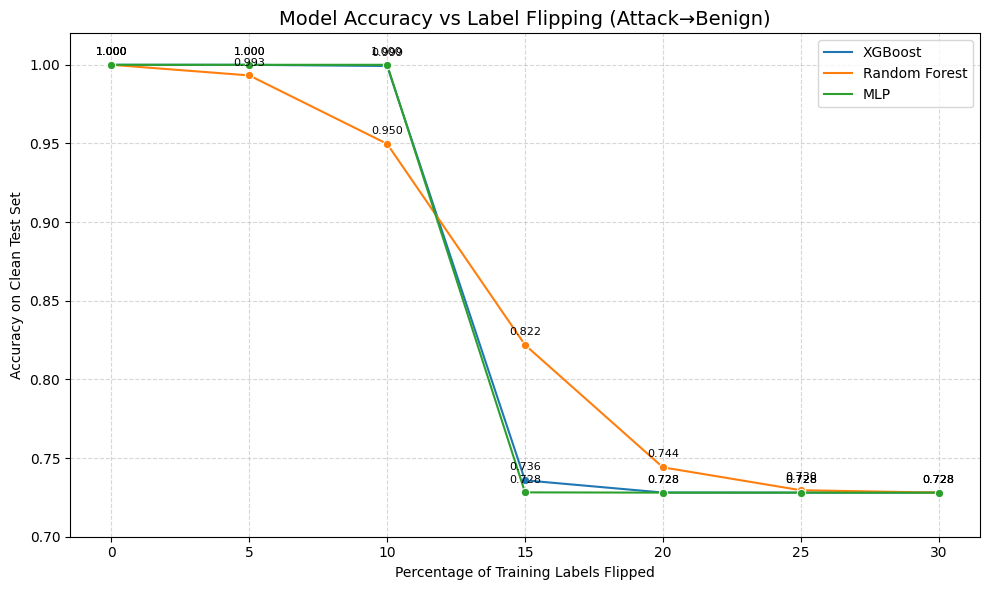

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have:
# flip_percentages, xgb_accuracies, rf_accuracies, mlp_accuracies

# 1) Build a DataFrame in “wide” form:
df_acc = pd.DataFrame({
    'Flip %': flip_percentages,
    'XGBoost': xgb_accuracies,
    'Random Forest': rf_accuracies,
    'MLP': mlp_accuracies
})

# 2) Melt to “long” form for Seaborn:
df_melt = df_acc.melt(id_vars='Flip %', 
                      var_name='Model', 
                      value_name='Accuracy')

# 3) Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melt, 
             x='Flip %', 
             y='Accuracy', 
             hue='Model', 
             marker='o')

# 4) Annotate each point
for model in df_melt['Model'].unique():
    sub = df_melt[df_melt['Model'] == model]
    for x, y in zip(sub['Flip %'], sub['Accuracy']):
        plt.text(x, y + 0.005, f"{y:.3f}", 
                 ha='center', va='bottom', 
                 fontsize=8)

plt.title("Model Accuracy vs Label Flipping (Attack→Benign)", fontsize=14)
plt.xlabel("Percentage of Training Labels Flipped")
plt.ylabel("Accuracy on Clean Test Set")
plt.ylim(0.70, 1.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='')
plt.tight_layout()
plt.show()


PART C

In [40]:
import hashlib

def generate_fingerprint(features, label):
    """
    Generate a hash (fingerprint) from a feature array and its label.
    """
    data_string = ','.join(map(str, features)) + f",{label}"
    return hashlib.sha256(data_string.encode()).hexdigest()


In [41]:
# Simulate secure storage (would be in secure enclave or database in practice)
trusted_fingerprints = {}

# Create fingerprints at the point of data labeling
for idx in range(len(X_train)):
    fingerprint = generate_fingerprint(X_train[idx], y_train.iloc[idx])
    trusted_fingerprints[idx] = fingerprint


In [42]:
tampered_indices = []

for idx in range(len(X_train)):
    current_fp = generate_fingerprint(X_train[idx], y_train.iloc[idx])
    if current_fp != trusted_fingerprints[idx]:
        tampered_indices.append(idx)

print(f"Detected {len(tampered_indices)} tampered label(s).")


Detected 0 tampered label(s).


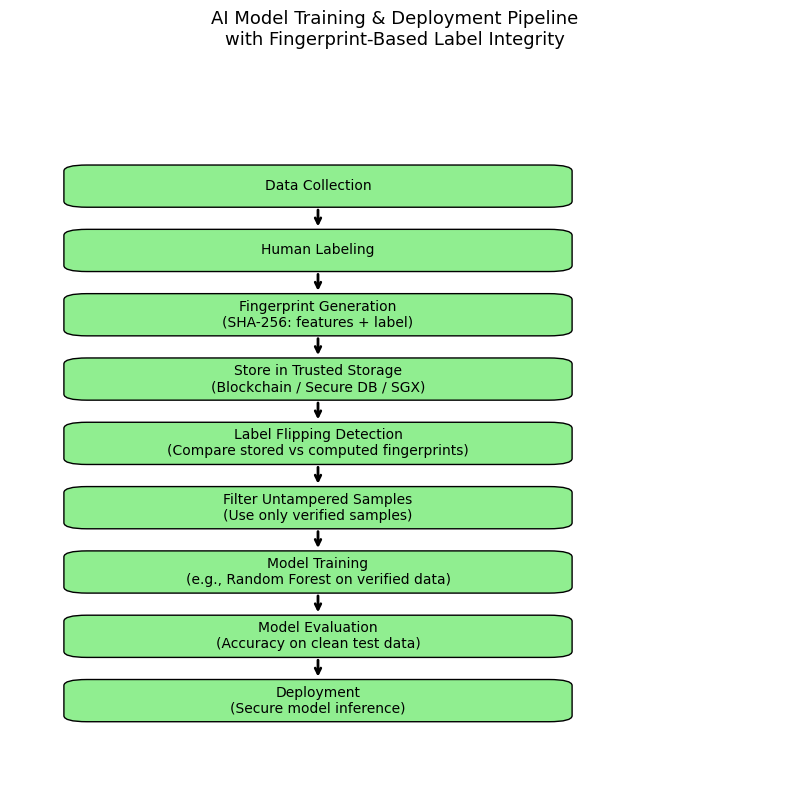

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Setup canvas
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis('off')

# Define pipeline stages
steps = [
    "Data Collection",
    "Human Labeling",
    "Fingerprint Generation\n(SHA-256: features + label)",
    "Store in Trusted Storage\n(Blockchain / Secure DB / SGX)",
    "Label Flipping Detection\n(Compare stored vs computed fingerprints)",
    "Filter Untampered Samples\n(Use only verified samples)",
    "Model Training\n(e.g., Random Forest on verified data)",
    "Model Evaluation\n(Accuracy on clean test data)",
    "Deployment\n(Secure model inference)"
]

# Positioning parameters
x_center = 4
box_width = 6
box_height = 1.5
y_spacing = 3.2
arrow_gap = 0.3

box_positions = []

# Draw labeled boxes
for i, text in enumerate(steps):
    y_top = (len(steps) - i) * y_spacing
    box_positions.append((x_center - box_width / 2, y_top))
    ax.add_patch(patches.FancyBboxPatch(
        (x_center - box_width / 2, y_top),
        box_width, box_height,
        boxstyle="round,pad=0.3", fc="#90ee90", ec="black"
    ))
    ax.text(x_center, y_top + box_height / 2, text, ha="center", va="center", fontsize=10)

# Connect boxes with arrows (visually accurate)
for i in range(len(box_positions) - 1):
    x = x_center
    y_start = box_positions[i][1] - arrow_gap
    y_end = box_positions[i + 1][1] + box_height + arrow_gap
    ax.annotate('', xy=(x, y_end), xytext=(x, y_start),
                arrowprops=dict(arrowstyle="->", lw=2.0, color='black'))

# Title and display settings
plt.title("AI Model Training & Deployment Pipeline\nwith Fingerprint-Based Label Integrity", fontsize=13, pad=20)
plt.xlim(0, 10)
plt.ylim(0, (len(steps) + 2) * y_spacing)
plt.tight_layout()

# Optional save
plt.savefig("Refined_Training_Pipeline_Flowchart.png", dpi=300, bbox_inches='tight')
plt.show()
